In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import PIL
from tensorflow import keras
from keras import layers
from keras.models import Sequential

In [28]:
## Map the data directory
data_dir = r"D:\Projects\MulticlassFishImageClassification\Project_data\data\train"
data_dir

'D:\\Projects\\MulticlassFishImageClassification\\Project_data\\data\\train'

In [29]:
from pathlib import Path
data_dir = Path(data_dir)
data_dir

WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train')

In [30]:
list(data_dir.glob('*/*.jpg'))

[WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/0055ESUKGS38.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/00H9IGEXR8N1.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/01KOCK58MEGR.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/02NB4GQNWVRW.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/04J91BOQEP2Q.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/05KGHV2JSURU.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/09HREQ5U6TO6.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/0DSM1NY3WE0O.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data

In [33]:
## No of classes of Fish in the dataset
len(list(data_dir.iterdir()))

11

In [35]:
## No of Tota Images available in the dataset
images_count = len(list(data_dir.glob('*/*.jpg')))
images_count

6225

#### Animal Fish count

In [37]:
animal_fish = list(data_dir.glob('animal fish/*.jpg'))
animal_fish_count = len(animal_fish)
animal_fish_count

1096

#### Visualize the fish image using PIL library

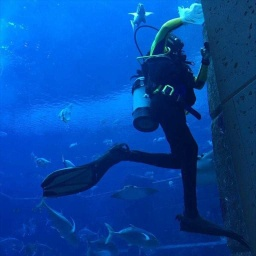

In [38]:
PIL.Image.open(animal_fish[0])

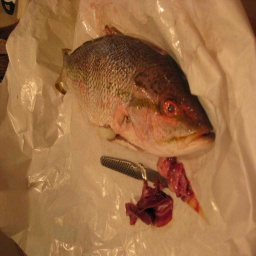

In [39]:
PIL.Image.open(animal_fish[1])

In [40]:
animal_fish_bass = list(data_dir.glob('animal fish bass/*.jpg'))
animal_fish_bass

[WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/068T3EQC3C0Q.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/0FOMFAGLZWI0.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/0JTHSXK1ETO7.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/1TTWRRBT5DYM.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/2VGLYRKAR81X.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/4KALDNCQFOSI.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/4STGWOPMPDYC.jpg'),
 WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish bass/4ZWTMDZL73G3.jpg'),
 WindowsPath('D:/Projects/Multic

In [41]:
animal_fish_bass_count = len(animal_fish_bass)
animal_fish_bass_count

30

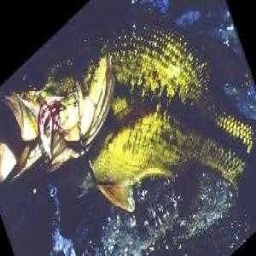

In [44]:
PIL.Image.open(animal_fish_bass[0])

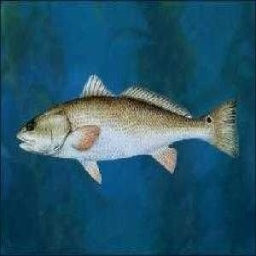

In [45]:
PIL.Image.open(animal_fish_bass[1])

#### Create Fish images path for each classes as Dictionary

In [48]:
fish_images_dict = {
    'animal fish' : list(data_dir.glob('animal fish/*')),
    'animal fish bass' : list(data_dir.glob('animal fish bass/*')),
    'fish sea_food black_sea_sprat' : list(data_dir.glob('fish sea_food black_sea_sprat/*')),
    'fish sea_food gilt_head_brea' : list(data_dir.glob('fish sea_food gilt_head_bream/*')),
    'fish sea_food hourse_mackerel' : list(data_dir.glob('fish sea_food hourse_mackerel/*')),
    'fish sea_food red_mullet' : list(data_dir.glob('fish sea_food red_mullet/*')),
    'fish sea_food red_sea_bream' : list(data_dir.glob('fish sea_food red_sea_bream/*')),
    'fish sea_food sea_bass' : list(data_dir.glob('fish sea_food sea_bass/*')),
    'fish sea_food shrimp' : list(data_dir.glob('fish sea_food shrimp/*')),
    'fish sea_food striped_red_mullet' : list(data_dir.glob('fish sea_food striped_red_mullet/*')),
    'fish sea_food trout' : list(data_dir.glob('fish sea_food trout/*')),
}

fish_images_dict

{'animal fish': [WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/0055ESUKGS38.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/00H9IGEXR8N1.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/01KOCK58MEGR.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/02NB4GQNWVRW.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/04J91BOQEP2Q.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/05KGHV2JSURU.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/09HREQ5U6TO6.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageClassification/Project_data/data/train/animal fish/0DSM1NY3WE0O.jpg'),
  WindowsPath('D:/Projects/MulticlassFishImageCla

#### Create Fish images labels for each classes as Dictionary

In [50]:
fish_labels_dict = {
    'animal fish' : 1,
    'animal fish bass' : 2,
    'fish sea_food black_sea_sprat' : 3,
    'fish sea_food gilt_head_brea' : 4,
    'fish sea_food hourse_mackerel' : 5,
    'fish sea_food red_mullet' : 6,
    'fish sea_food red_sea_bream' : 7,
    'fish sea_food sea_bass' : 8,
    'fish sea_food shrimp' : 9,
    'fish sea_food striped_red_mullet' : 10,
    'fish sea_food trout' : 11,
}
fish_labels_dict

{'animal fish': 1,
 'animal fish bass': 2,
 'fish sea_food black_sea_sprat': 3,
 'fish sea_food gilt_head_brea': 4,
 'fish sea_food hourse_mackerel': 5,
 'fish sea_food red_mullet': 6,
 'fish sea_food red_sea_bream': 7,
 'fish sea_food sea_bass': 8,
 'fish sea_food shrimp': 9,
 'fish sea_food striped_red_mullet': 10,
 'fish sea_food trout': 11}

#### Using OpenCV to Load Images from Folder

In [53]:
print(type(fish_labels_dict['animal fish']))


<class 'int'>


In [54]:
img = cv2.imread(fish_images_dict['animal fish'][0])
img

array([[[245, 131,   0],
        [250, 137,   3],
        [250, 137,   3],
        ...,
        [107,  62,  19],
        [108,  56,  20],
        [110,  56,  25]],

       [[248, 134,   3],
        [252, 139,   5],
        [252, 140,   4],
        ...,
        [109,  64,  21],
        [109,  59,  23],
        [110,  57,  24]],

       [[250, 137,   3],
        [253, 140,   6],
        [253, 141,   5],
        ...,
        [106,  61,  17],
        [109,  60,  22],
        [108,  58,  22]],

       ...,

       [[132,  40,   0],
        [135,  40,   0],
        [138,  42,   2],
        ...,
        [ 73,  39,  10],
        [ 69,  36,  10],
        [ 69,  39,  12]],

       [[130,  39,   0],
        [131,  40,   1],
        [135,  42,   3],
        ...,
        [ 73,  39,  10],
        [ 66,  33,   7],
        [ 68,  35,   9]],

       [[127,  39,   0],
        [128,  40,   0],
        [134,  41,   2],
        ...,
        [ 67,  33,   3],
        [ 73,  38,  12],
        [ 68,  35,   9]]

In [55]:
img.shape

(256, 256, 3)

#### verify that all images are 256×256 using Python with Pillow library


In [56]:
from PIL import Image
unique_res_images = []
images_path = list(data_dir.rglob('*.jpg'))
for image_path in images_path:
    with Image.open(image_path) as img:
        if img.size != (256,256):
            unique_res_images.append(image_path, img.size)
print(f"Total images: {len(images_path)}")
print(f"Wrong resolution images: {len(unique_res_images)}")
print(unique_res_images[:10])

Total images: 6225
Wrong resolution images: 0
[]


### Interpretation
##### Total Images found : 6225
##### All images are exactly in the same resolution that is 256 * 256
##### No resizing or Cleaning Needed for this dataset